# Transformers

## Part 1 - Data Preprocessing

### Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

### Importing the dataset

In [2]:
dataset = pd.read_csv("Telco-Customer-Churn.csv")
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Creating input text

In [3]:
dataset = dataset[["InternetService","Contract","PaymentMethod","Churn"]]
dataset.dropna(inplace = True)
dataset.head()

,InternetService,Contract,PaymentMethod,Churn
0,DSL,Month-to-month,Electronic check,No
1,DSL,One year,Mailed check,No
2,DSL,Month-to-month,Mailed check,Yes
3,DSL,One year,Bank transfer (automatic),No
4,Fiber optic,Month-to-month,Electronic check,Yes


In [4]:
dataset["text"] = (dataset["InternetService"] + " " + dataset["Contract"] + " " + dataset["PaymentMethod"])

### Encoding labels

In [5]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

dataset["Churn"] = encoder.fit_transform(dataset["Churn"])

### Splitting the dataset into training set and test set

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    dataset["text"],
    dataset["Churn"],
    test_size = 0.2,
    random_state = 0
)

## Part 2 - Building and Training the Transformer

### Importing the Keras libraries and packages

In [8]:
from keras.models import Model
from keras.layers import (
    TextVectorization, Embedding, MultiHeadAttention, LayerNormalization,
    Dense, Dropout, GlobalAveragePooling1D, Input, Layer
)

### Applying Text Veectorization

In [9]:
VOCAB_SIZE = 1000
SEQUENCE_LENGTH = 10

vectorizer = TextVectorization(
    max_tokens = VOCAB_SIZE,
    output_sequence_length = SEQUENCE_LENGTH
)

vectorizer.adapt(X_train)

In [10]:
X_train = vectorizer(np.array(X_train))
X_test = vectorizer(np.array(X_test))

### Positional Encoding Layer

In [11]:
class PositionalEmbedding(Layer):

    def __init__(self, sequence_length, vocab_size, embed_dim):

        super().__init__()

        self.token_embeddings = Embedding(
            input_dim = vocab_size,
            output_dim = embed_dim
        )

        self.position_embeddings = Embedding(
            input_dim = sequence_length,
            output_dim = embed_dim
        )

        self.sequence_length = sequence_length

    def call(self, inputs):

        positions = tf.range(start = 0, limit = self.sequence_length)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)

        return embedded_tokens + embedded_positions

## Transformer encoder block

In [12]:
class TransformerEncoder(Layer):

    def __init__(self, embed_dim, dense_dim, num_heads):

        super().__init__()

        self.attention = MultiHeadAttention(
            num_heads = num_heads,
            key_dim = embed_dim
        )

        self.dense = tf.keras.Sequential([
            Dense(dense_dim, activation = "relu"),
            Dense(embed_dim)
        ])

        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()

        self.dropout1 = Dropout(0.1)
        self.dropout2 = Dropout(0.1)

    def call(self, inputs, training = False):

        attention_output = self.attention(
            inputs,
            inputs
        )

        attention_output = self.dropout1(
            attention_output,
            training = training
        )

        normal_output = self.layernorm1(
            inputs + attention_output
        )

        dense_output = self.dense(normal_output)

        dense_output = self.dropout2(
            dense_output,
            training = training
        )

        return self.layernorm2(
            normal_output + dense_output
        )

## Building the transformer model

In [13]:
EMBEDDING_DIM = 32
NUM_HEADS = 2
DENSE_DIM = 64

inputs = Input(
    shape = (SEQUENCE_LENGTH, )
)

### Adding positional encoding layer

In [14]:
x = PositionalEmbedding(
    SEQUENCE_LENGTH,
    VOCAB_SIZE,
    EMBEDDING_DIM
)(inputs)

### Adding encoder layer

In [15]:
x = TransformerEncoder(
    EMBEDDING_DIM,
    DENSE_DIM,
    NUM_HEADS
)(x)

### Adding dense layers

In [16]:
x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)

x = Dense(
    32,
    activation = "relu"
)(x)

outputs = Dense(
    1,
    activation = "sigmoid"
)(x)

### Making the model with inputs and outputs

In [17]:
model = Model(inputs, outputs)

### Getting model summary

In [18]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 10, 32)         │        32,320 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 10, 32)         │        12,736 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,145 (180.25 KB)

 Trainable params: 46,145 (180.25 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Transformer

In [19]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

### Fitting the transformer to the training set

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs = 10,
    batch_size = 32,
    validation_split = 0.2
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.7435 - loss: 0.4845 - val_accuracy: 0.8057 - val_loss: 0.4137
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7579 - loss: 0.4616 - val_accuracy: 0.8057 - val_loss: 0.4149
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7566 - loss: 0.4594 - val_accuracy: 0.7995 - val_loss: 0.4165
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7606 - loss: 0.4587 - val_accuracy: 0.7524 - val_loss: 0.4205
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7628 - loss: 0.4603 - val_accuracy: 0.8057 - val_loss: 0.4137
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7621 - loss: 0.4566 - val_accuracy: 0.7764 - val_loss: 0.4434
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7644 - loss: 0.4574 - val_accuracy: 0.7995 - val_loss: 0.4201
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7639 - loss: 0.4541 - val_accuracy: 

### Evaluating the transformer

In [21]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7672 - loss: 0.4599


In [22]:
print("Accuracy :", accuracy)

Accuracy : 0.7672107815742493


## Part 3 - Making the predictions and visualising the results

### Predicting the test set

In [23]:
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int)
predictions[:10]

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1]])

In [31]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions.flatten()
})

results.head(5)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


### Making the confusion matrix

In [32]:
from sklearn.metrics import confusion_matrix

In [33]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[923 118]
 [210 158]]


### Predicting new customers

In [24]:
sample = ["Fiber optic Month-to-month Electronic check"]
sample = vectorizer(sample)

In [25]:
prediction = model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [26]:
if prediction > 0.5:
    print("Customer is likely to leave.")
else:
    print("Customer is likely to stay.")

Customer is likely to leave.


### Visualising accuracy and loss

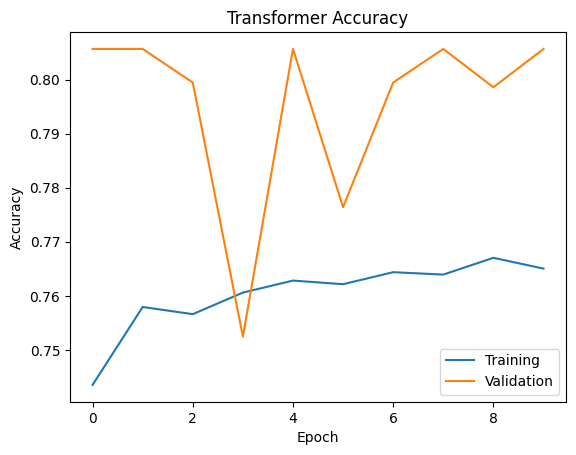

In [27]:
plt.plot(history.history["accuracy"], label = "Training")
plt.plot(history.history["val_accuracy"], label = "Validation")

plt.title("Transformer Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

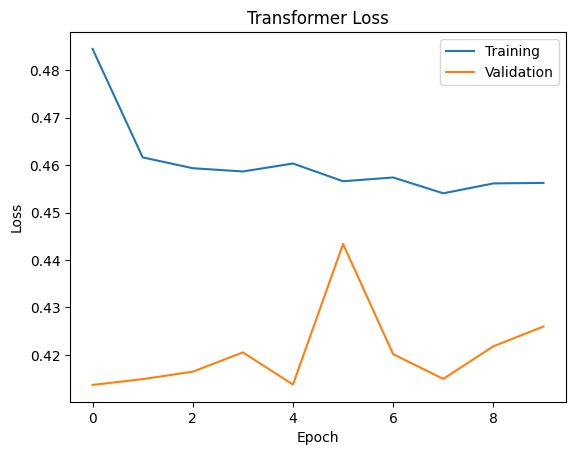

In [28]:
plt.plot(history.history["loss"], label = "Training")
plt.plot(history.history["val_loss"], label = "Validation")

plt.title("Transformer Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()